# Catalog RSD validation walkthrough

This notebook is the RSD counterpart of `catalog_bao_validation.ipynb`. It documents and inspects the catalog-level RSD blinding validation ladder for `desiblind` against the DESI LSS reference implementation.

The key RSD redshift transform being validated is

$$
\chi_{\rm blind} = \chi_{\rm real} + \frac{f_{\rm blind}}{f_{\rm fid}}\left(\chi_{\rm obs} - \chi_{\rm real}\right).
$$

Here `χ_real` comes from the LSS `IFFTrsd` reconstruction output. The validation checks that `CatalogRSDBlinder` matches `LSS.blinding_tools.apply_zshift_RSD` first directly, then through saved catalogs, reconstruction, and final `desi-clustering` statistics.


## Validation ladder

The RSD ladder mirrors the BAO/AP validation style, but the reconstruction piece is RSD-specific.

1. **Core/unit tests**: test `CatalogRSDBlinder` formulas and parameter-bank I/O.
2. **Direct redshift-shift check**: compare `CatalogRSDBlinder` to `LSS.apply_zshift_RSD` on a toy catalog.
3. **Real-subset reconstruction check**: run LSS `IFFTrsd` reconstruction on real NGC/SGC subsets, then compare the RSD redshift shift.
4. **Saved-catalog check**: run BAO/AP saved full catalogs, `mkclusdat`, `mkclusran`, GC splitting, `IFFTrsd` reconstruction, and final RSD redshift shifting.
5. **Measurement-layer check**: feed final RSD-blinded LSS/desiblind catalogs through `desi-clustering.compute_stats_from_options` for Pk and xi.

Important convention reminder:

- `convention='rsd'` / `IFFTrsd` estimates the line-of-sight RSD displacement needed for RSD blinding.
- `reciso` and `recsym` are BAO post-reconstruction conventions and are not the real-space catalog used for RSD blinding.


In [1]:
from pathlib import Path
import json
import os
import sys

import numpy as np
import matplotlib.pyplot as plt

try:
    import pandas as pd
except ImportError:
    pd = None

from IPython.display import display, Markdown

REPO_ROOT = Path('/global/homes/u/uendert/repos/desi/desiblind')
VALIDATION_BASE = Path('/pscratch/sd/u/uendert/desiblind_lss_validation')

SUMMARY_PATHS = {
    'direct_toy': VALIDATION_BASE / 'rsd-redshift-shift-20260626-154626-540012/summary.json',
    'recon_ngc': VALIDATION_BASE / 'rsd-recon-shift-20260626-201203-1234847/summary.json',
    'recon_sgc': VALIDATION_BASE / 'rsd-recon-shift-20260626-201300-1235312/summary.json',
    'saved_small': VALIDATION_BASE / 'rsd-saved-catalog-20260629-154659-1398399/summary.json',
    'saved_large': VALIDATION_BASE / 'rsd-saved-catalog-20260629-160133-759367/summary.json',
    'saved_fullrow': VALIDATION_BASE / 'rsd-saved-catalog-fullrow-ran0-lssrecon-20260630-132632-308997/summary.json',
    'driver_backends': VALIDATION_BASE / 'rsd-desi-clustering-driver-20260630-185228-1058512/summary.json',
    'pk_stats': VALIDATION_BASE / 'rsd-desi-clustering-stats-20260629-160601-1746031/summary.json',
    'xi_stats': VALIDATION_BASE / 'rsd-desi-clustering-stats-20260629-160817-905849/summary.json',
}

for key, path in SUMMARY_PATHS.items():
    if not path.exists():
        raise FileNotFoundError(f'{key}: {path}')

summaries = {key: json.loads(path.read_text()) for key, path in SUMMARY_PATHS.items()}
print('Loaded summaries:')
for key, path in SUMMARY_PATHS.items():
    print(f'  {key:12s} {path}')


Loaded summaries:
  direct_toy   /pscratch/sd/u/uendert/desiblind_lss_validation/rsd-redshift-shift-20260626-154626-540012/summary.json
  recon_ngc    /pscratch/sd/u/uendert/desiblind_lss_validation/rsd-recon-shift-20260626-201203-1234847/summary.json
  recon_sgc    /pscratch/sd/u/uendert/desiblind_lss_validation/rsd-recon-shift-20260626-201300-1235312/summary.json
  saved_small  /pscratch/sd/u/uendert/desiblind_lss_validation/rsd-saved-catalog-20260629-154659-1398399/summary.json
  saved_large  /pscratch/sd/u/uendert/desiblind_lss_validation/rsd-saved-catalog-20260629-160133-759367/summary.json
  saved_fullrow /pscratch/sd/u/uendert/desiblind_lss_validation/rsd-saved-catalog-fullrow-ran0-lssrecon-20260630-132632-308997/summary.json
  driver_backends /pscratch/sd/u/uendert/desiblind_lss_validation/rsd-desi-clustering-driver-20260630-185228-1058512/summary.json
  pk_stats     /pscratch/sd/u/uendert/desiblind_lss_validation/rsd-desi-clustering-stats-20260629-160601-1746031/summary.json
 

## Helpers


In [2]:
def as_table(rows, columns=None):
    if pd is not None:
        df = pd.DataFrame(rows, columns=columns)
        display(df)
        return df
    for row in rows:
        print(row)
    return rows


def max_delta_from_comparison(comp):
    for key in ['max_abs_delta_Z', 'max_abs_delta', 'max_abs_delta_WEIGHT', 'max_abs_delta_WEIGHT_SYS']:
        if key in comp and comp[key] is not None:
            return comp[key]
    return None


def summarize_direct_and_recon():
    rows = []
    toy = summaries['direct_toy']['validations'][0]
    rows.append({
        'stage': 'direct_toy',
        'region': 'toy',
        'rows': toy['rows'],
        'max_abs_delta_Z': toy['max_abs_delta_Z'],
        'status': 'PASS',
        'summary': str(SUMMARY_PATHS['direct_toy']),
    })
    for key, region in [('recon_ngc', 'NGC'), ('recon_sgc', 'SGC')]:
        comp = summaries[key]['comparison']
        rows.append({
            'stage': 'real_reconstruction',
            'region': region,
            'rows': comp['rows'],
            'max_abs_delta_Z': comp['max_abs_delta_Z'],
            'status': summaries[key].get('status', 'PASS'),
            'summary': str(SUMMARY_PATHS[key]),
        })
    return rows


def summarize_saved_catalog(key):
    summary = summaries[key]
    rows = []
    for region, result in summary['rsd_regions'].items():
        comp = result['comparison']
        rows.append({
            'product': key,
            'region': region,
            'input_full_rows': summary['nrows'],
            'random_rows': summary['random_rows'],
            'final_rows': comp['rows'],
            'max_abs_delta_Z': comp['max_abs_delta_Z'],
            'max_abs_delta_WEIGHT': comp['max_abs_delta_WEIGHT'],
            'max_abs_delta_WEIGHT_SYS': comp['max_abs_delta_WEIGHT_SYS'],
            'max_abs_delta_WEIGHT_FKP': comp['max_abs_delta_WEIGHT_FKP'],
            'summary': str(SUMMARY_PATHS[key]),
        })
    return rows


def flatten_stats_summary(key):
    summary = summaries[key]
    rows = []
    for region, files in summary['comparisons'].items():
        for filename, comp in files.items():
            rows.append({
                'product': key,
                'region': region,
                'file': filename,
                'stat': summary['stats'][0],
                'max_abs_delta': comp['max_abs_delta'],
                'sample_data_rows': summary['sample_data_rows'],
                'sample_random_rows': summary['sample_random_rows'],
                'summary': str(SUMMARY_PATHS[key]),
            })
    return rows


def assert_zero_or_roundoff(value, atol=1e-12):
    if not np.isfinite(value) or abs(value) > atol:
        raise AssertionError(f'{value} exceeds tolerance {atol}')



def flatten_driver_backend_summary(key='driver_backends'):
    summary = summaries[key]
    rows = []
    for backend, regions in summary['results'].items():
        for region, result in regions.items():
            rows.append({
                'backend': backend,
                'region': region,
                'rows': result['rows'],
                'runtime_seconds': result['runtime_seconds'],
                'max_abs_realspace_delta_Z': result['realspace_delta_Z_vs_lss']['max_abs'],
                'max_abs_blinded_delta_Z': result['blinded_delta_Z_vs_lss']['max_abs'],
                'threshold_method': result['driver_summary']['reconstruction']['threshold_randoms_method'],
                'boxcenter': result['driver_summary']['reconstruction']['boxcenter'],
                'summary': str(SUMMARY_PATHS[key]),
            })
    return rows


## RSD parameters and the growth-rate blind

The saved-catalog and measurement-layer validations use the same RSD parameters. The fiducial LRG values are `f_fid=0.8` and `bias=2.0`; the selected BAO/AP blind is `w0=-0.95`, `wa=0.10`. The derived RSD value is clipped at the DESI/LSS 10% cap.


In [3]:
params = summaries['saved_large']['parameters_rsd']
as_table([params])
print(f"f_blind / f_fid = {params['fgrowth_blind'] / params['fiducial_f']:.6f}")


,bias,fgrowth_blind,fiducial_f,max_df_fraction,w0,wa,zeff
0,2.0,0.88,0.8,0.1,-0.95,0.1,0.8


f_blind / f_fid = 1.100000


## 1. Direct and shared-reconstruction checks

These checks isolate the RSD redshift transform itself. The toy check uses a tiny self-contained catalog. The real-subset checks use LSS `IFFTrsd` reconstructed-realspace catalogs for NGC and SGC.


In [4]:
direct_recon_rows = summarize_direct_and_recon()
as_table(direct_recon_rows)
for row in direct_recon_rows:
    assert_zero_or_roundoff(row['max_abs_delta_Z'])
print('direct_and_reconstruction_checks=PASS')


,stage,region,rows,max_abs_delta_Z,status,summary
0,direct_toy,toy,4,0.0,PASS,/pscratch/sd/u/uendert/desiblind_lss_validatio...
1,real_reconstruction,NGC,2000,0.0,PASS,/pscratch/sd/u/uendert/desiblind_lss_validatio...
2,real_reconstruction,SGC,2000,0.0,PASS,/pscratch/sd/u/uendert/desiblind_lss_validatio...


direct_and_reconstruction_checks=PASS


### RSD displacement visualization from the real-subset checks

For the real-subset NGC/SGC validation products, compare the fiducial observed displacement and the blinded displacement relative to the reconstructed-realspace catalog:

- fiducial displacement: `χ_obs - χ_real`
- blinded displacement: `χ_blind - χ_real`

The ratio should track `f_blind / f_fid = 1.1` away from very small denominators.


NGC
  fiducial displacement min/max: -488.42079891522144 1050.4271478089454
  blinded displacement min/max:  -537.2628790965223 1155.4698623513118
  max |blind - ratio*fid|:       3.1130088018471724e-07
SGC
  fiducial displacement min/max: -216.64224351217763 317.56608591359236
  blinded displacement min/max:  -238.30646789490265 349.322694250744
  max |blind - ratio*fid|:       3.055159112363981e-07


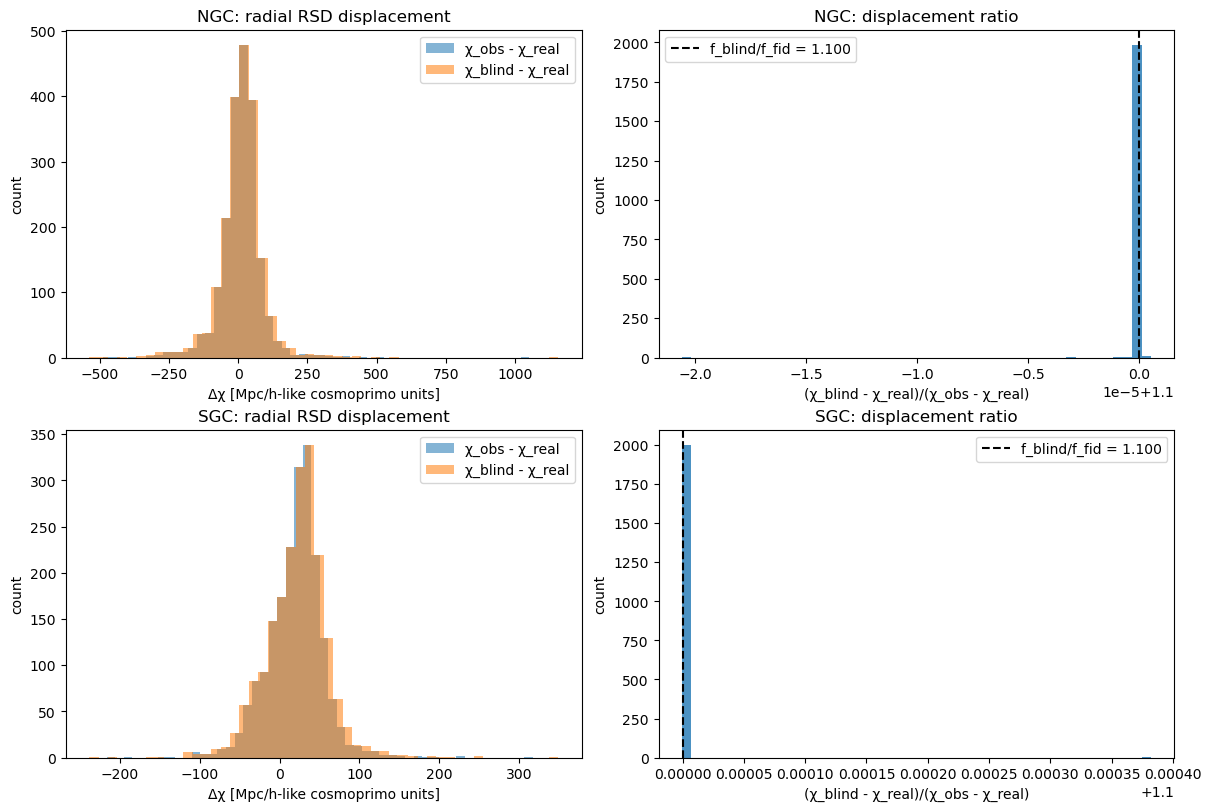

In [5]:
import fitsio
from astropy.table import Table

try:
    from cosmoprimo.fiducial import DESI
    cosmo = DESI()
    distance = cosmo.comoving_radial_distance
except Exception as exc:
    raise RuntimeError('cosmoprimo DESI cosmology is required for this notebook cell') from exc

fig, axes = plt.subplots(2, 2, figsize=(12, 8), constrained_layout=True)
ratio_target = params['fgrowth_blind'] / params['fiducial_f']

for i, (key, region) in enumerate([('recon_ngc', 'NGC'), ('recon_sgc', 'SGC')]):
    files = summaries[key]['files']
    observed = Table(fitsio.read(files['observed_sample'], ext='LSS'))
    realspace = Table(fitsio.read(files['realspace_reconstruction'], ext='LSS'))
    blinded = Table(fitsio.read(files['lss_rsd_blinded'], ext='LSS'))

    chi_obs = distance(np.asarray(observed['Z']))
    chi_real = distance(np.asarray(realspace['Z']))
    chi_blind = distance(np.asarray(blinded['Z']))

    fid_disp = chi_obs - chi_real
    blind_disp = chi_blind - chi_real
    residual = blind_disp - ratio_target * fid_disp
    good = np.abs(fid_disp) > 1e-8
    ratio = np.full_like(fid_disp, np.nan, dtype='f8')
    ratio[good] = blind_disp[good] / fid_disp[good]

    axes[i, 0].hist(fid_disp, bins=50, alpha=0.55, label='χ_obs - χ_real')
    axes[i, 0].hist(blind_disp, bins=50, alpha=0.55, label='χ_blind - χ_real')
    axes[i, 0].set_title(f'{region}: radial RSD displacement')
    axes[i, 0].set_xlabel('Δχ [Mpc/h-like cosmoprimo units]')
    axes[i, 0].set_ylabel('count')
    axes[i, 0].legend()

    axes[i, 1].hist(ratio[good], bins=50, alpha=0.8)
    axes[i, 1].axvline(ratio_target, color='k', ls='--', label=f'f_blind/f_fid = {ratio_target:.3f}')
    axes[i, 1].set_title(f'{region}: displacement ratio')
    axes[i, 1].set_xlabel('(χ_blind - χ_real)/(χ_obs - χ_real)')
    axes[i, 1].set_ylabel('count')
    axes[i, 1].legend()

    print(region)
    print('  fiducial displacement min/max:', float(np.min(fid_disp)), float(np.max(fid_disp)))
    print('  blinded displacement min/max: ', float(np.min(blind_disp)), float(np.max(blind_disp)))
    print('  max |blind - ratio*fid|:      ', float(np.max(np.abs(residual))))


## 2. Saved-catalog RSD ladder

The saved-catalog validator runs the whole integration path through BAO/AP saved full catalogs, `mkclusdat`, `mkclusran`, GC splitting, `IFFTrsd` reconstruction, and final RSD blinding. The LSS branch and desiblind branch are compared at the final RSD-blinded clustering-catalog level.


A full-row one-random LSS-reference saved-catalog run also passes (`saved_fullrow`), with zero final `Z` and checked-weight deltas for NGC and SGC.

In [6]:
saved_rows = summarize_saved_catalog('saved_small') + summarize_saved_catalog('saved_large') + summarize_saved_catalog('saved_fullrow')
as_table(saved_rows)
for row in saved_rows:
    for col in ['max_abs_delta_Z', 'max_abs_delta_WEIGHT', 'max_abs_delta_WEIGHT_SYS', 'max_abs_delta_WEIGHT_FKP']:
        assert_zero_or_roundoff(row[col])
print('saved_catalog_rsd_checks=PASS')


,product,region,input_full_rows,random_rows,final_rows,max_abs_delta_Z,max_abs_delta_WEIGHT,max_abs_delta_WEIGHT_SYS,max_abs_delta_WEIGHT_FKP,summary
0,saved_small,NGC,8000,20000,2898,0.0,0.0,0.0,0.0,/pscratch/sd/u/uendert/desiblind_lss_validatio...
1,saved_small,SGC,8000,20000,2012,0.0,0.0,0.0,0.0,/pscratch/sd/u/uendert/desiblind_lss_validatio...
2,saved_large,NGC,50000,200000,18573,0.0,0.0,0.0,0.0,/pscratch/sd/u/uendert/desiblind_lss_validatio...
3,saved_large,SGC,50000,200000,14716,0.0,0.0,0.0,0.0,/pscratch/sd/u/uendert/desiblind_lss_validatio...
4,saved_fullrow,NGC,0,25061644,2959450,0.0,0.0,0.0,0.0,/pscratch/sd/u/uendert/desiblind_lss_validatio...
5,saved_fullrow,SGC,0,25061644,1520256,0.0,0.0,0.0,0.0,/pscratch/sd/u/uendert/desiblind_lss_validatio...


saved_catalog_rsd_checks=PASS


### Saved-catalog reconstruction settings

The validation uses the LSS RSD reconstruction convention (`convention='rsd'`) and the same DR-style smoothing radius (`15 Mpc/h`). The explicit `boxsize=6000` is a validation-geometry setting for sky-wide sampled catalogs, not a new physics choice.


In [7]:
recon = summaries['saved_large']['reconstruction']
as_table([recon])


,boxsize,cellsize,convention,label,method,nmesh,nthreads,smoothing_radius
0,6000.0,7.0,rsd,IFFTrsd,iterative_fft,64,16,15.0


,boxsize,cellsize,convention,label,method,nmesh,nthreads,smoothing_radius
0,6000.0,7.0,rsd,IFFTrsd,iterative_fft,64,16,15.0


### Final saved-catalog Z equality

The final LSS and desiblind RSD-blinded catalogs should be identical. This cell directly verifies the final `Z` arrays for the larger saved-catalog validation and displays the final redshift distributions.


NGC rows 18573 max |ΔZ| 0.0
SGC rows 14716 max |ΔZ| 0.0


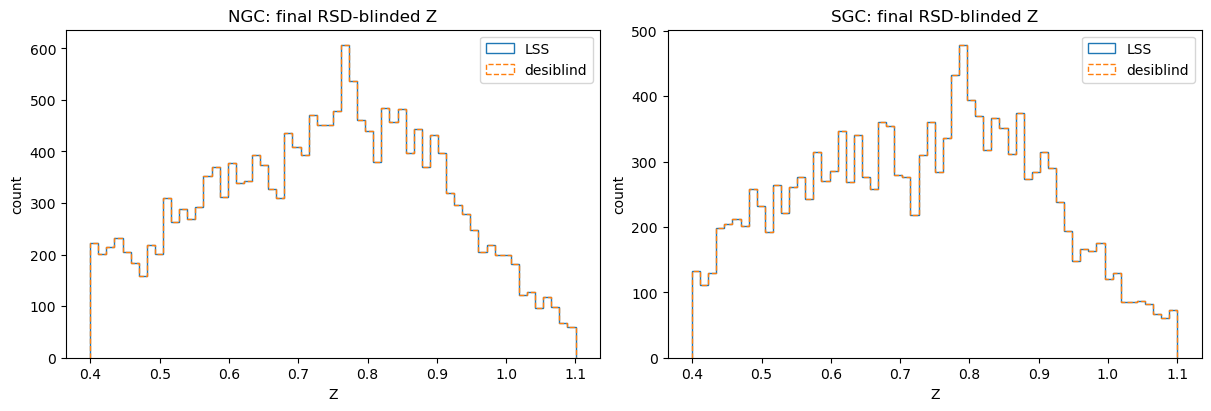

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4), constrained_layout=True)
for ax, region in zip(axes, ['NGC', 'SGC']):
    result = summaries['saved_large']['rsd_regions'][region]
    lss_fn = result['branches']['lss']['rsd_blinded_data']
    desi_fn = result['branches']['desiblind']['rsd_blinded_data']
    lss = fitsio.read(lss_fn, ext='LSS')
    desi = fitsio.read(desi_fn, ext='LSS')
    dz = desi['Z'] - lss['Z']
    assert_zero_or_roundoff(float(np.max(np.abs(dz))))
    ax.hist(lss['Z'], bins=60, histtype='step', label='LSS')
    ax.hist(desi['Z'], bins=60, histtype='step', ls='--', label='desiblind')
    ax.set_title(f'{region}: final RSD-blinded Z')
    ax.set_xlabel('Z')
    ax.set_ylabel('count')
    ax.legend()
    print(region, 'rows', len(lss), 'max |ΔZ|', float(np.max(np.abs(dz))))


## 3. `desi-clustering` saved-catalog driver backends

The user-facing `desi-clustering` catalog driver can now compute the reconstructed-realspace catalog without importing LSS. This validation runs both computed backends against the existing LSS/pyrecon 2k-row NGC/SGC references:

- `--run-pyrecon`: direct pyrecon wrapper; reference-compatible non-LSS backend.
- `--run-jaxrecon`: JAX-native backend; matched to pyrecon conventions by using the data-derived pyrecon box center and `threshold_randoms_method='mean'`.

Both backends are required to match the LSS/pyrecon final RSD-blinded `Z` at numerical precision in the latest validation.


In [9]:
driver_rows = flatten_driver_backend_summary('driver_backends')
as_table(driver_rows)
for row in driver_rows:
    assert_zero_or_roundoff(row['max_abs_blinded_delta_Z'], atol=1e-7)
print('desi_clustering_driver_backend_validation=PASS')


,backend,region,rows,runtime_seconds,max_abs_realspace_delta_Z,max_abs_blinded_delta_Z,threshold_method,boxcenter,summary
0,jaxrecon,NGC,2000,5.307660,2.526811e-08,2.462318e-09,mean,"[-1014.1634319732871, -129.1010922057044, 918....",/pscratch/sd/u/uendert/desiblind_lss_validatio...
1,jaxrecon,SGC,2000,0.891683,2.537961e-08,2.552666e-09,mean,"[1367.7685124104116, 275.637196708867, 248.270...",/pscratch/sd/u/uendert/desiblind_lss_validatio...
2,pyrecon,NGC,2000,5.745096,2.526811e-08,2.462318e-09,mean,None,/pscratch/sd/u/uendert/desiblind_lss_validatio...
3,pyrecon,SGC,2000,1.010090,2.537961e-08,2.552666e-09,mean,None,/pscratch/sd/u/uendert/desiblind_lss_validatio...


desi_clustering_driver_backend_validation=PASS


## 4. Final statistics through `desi-clustering`

The measurement-layer checks consume the larger saved-catalog RSD output and run `desi-clustering.compute_stats_from_options` on the LSS and desiblind branches.


In [10]:
stats_rows = flatten_stats_summary('pk_stats') + flatten_stats_summary('xi_stats')
as_table(stats_rows)
for row in stats_rows:
    assert_zero_or_roundoff(row['max_abs_delta'])
print('measurement_layer_summary_checks=PASS')


,product,region,file,stat,max_abs_delta,sample_data_rows,sample_random_rows,summary
0,pk_stats,NGC,mesh2_spectrum_poles_LRG_z0.4-1.1_NGC_weight-d...,mesh2_spectrum,0.000000e+00,0,0,/pscratch/sd/u/uendert/desiblind_lss_validatio...
1,pk_stats,SGC,mesh2_spectrum_poles_LRG_z0.4-1.1_SGC_weight-d...,mesh2_spectrum,0.000000e+00,0,0,/pscratch/sd/u/uendert/desiblind_lss_validatio...
2,xi_stats,NGC,particle2_correlation_smu_LRG_z0.4-1.1_NGC_wei...,particle2_correlation,1.626303e-19,0,50000,/pscratch/sd/u/uendert/desiblind_lss_validatio...
3,xi_stats,SGC,particle2_correlation_smu_LRG_z0.4-1.1_SGC_wei...,particle2_correlation,3.252607e-19,0,50000,/pscratch/sd/u/uendert/desiblind_lss_validatio...


measurement_layer_summary_checks=PASS


### HDF5 dataset comparisons

Every numeric dataset in each LSS/desiblind HDF5 product is compared. This flattens the per-dataset deltas so the result is inspectable beyond the single max value.


In [11]:
def flatten_hdf5_comparisons(summary_key):
    rows = []
    summary = summaries[summary_key]
    for region, files in summary['comparisons'].items():
        for filename, comp in files.items():
            for dataset, delta in comp['datasets'].items():
                rows.append({
                    'product': summary_key,
                    'region': region,
                    'file': filename,
                    'dataset': dataset,
                    'max_abs_delta': delta,
                })
    return rows

hdf5_rows = flatten_hdf5_comparisons('pk_stats') + flatten_hdf5_comparisons('xi_stats')
if pd is not None:
    display(pd.DataFrame(hdf5_rows).sort_values('max_abs_delta', ascending=False).head(20))
else:
    for row in sorted(hdf5_rows, key=lambda r: r['max_abs_delta'], reverse=True)[:20]:
        print(row)


,product,region,file,dataset,max_abs_delta
162,xi_stats,SGC,particle2_correlation_smu_LRG_z0.4-1.1_SGC_wei...,SS/normalized_counts,3.252607e-19
144,xi_stats,SGC,particle2_correlation_smu_LRG_z0.4-1.1_SGC_wei...,RR/normalized_counts,3.252607e-19
135,xi_stats,SGC,particle2_correlation_smu_LRG_z0.4-1.1_SGC_wei...,DS/normalized_counts,2.710505e-19
126,xi_stats,SGC,particle2_correlation_smu_LRG_z0.4-1.1_SGC_wei...,DD/normalized_counts,2.168404e-19
153,xi_stats,SGC,particle2_correlation_smu_LRG_z0.4-1.1_SGC_wei...,SD/normalized_counts,2.168404e-19
95,xi_stats,NGC,particle2_correlation_smu_LRG_z0.4-1.1_NGC_wei...,RR/normalized_counts,1.626303e-19
113,xi_stats,NGC,particle2_correlation_smu_LRG_z0.4-1.1_NGC_wei...,SS/normalized_counts,1.626303e-19
104,xi_stats,NGC,particle2_correlation_smu_LRG_z0.4-1.1_NGC_wei...,SD/normalized_counts,8.131516e-20
77,xi_stats,NGC,particle2_correlation_smu_LRG_z0.4-1.1_NGC_wei...,DD/normalized_counts,6.776264e-20
86,xi_stats,NGC,particle2_correlation_smu_LRG_z0.4-1.1_NGC_wei...,DS/normalized_counts,5.421011e-20


### Pk multipole overlay and residuals

The Pk products should overlay exactly because the final input catalogs match exactly.


NGC ell=0 max residual 0.0
NGC ell=2 max residual 0.0
NGC ell=4 max residual 0.0
SGC ell=0 max residual 0.0
SGC ell=2 max residual 0.0
SGC ell=4 max residual 0.0


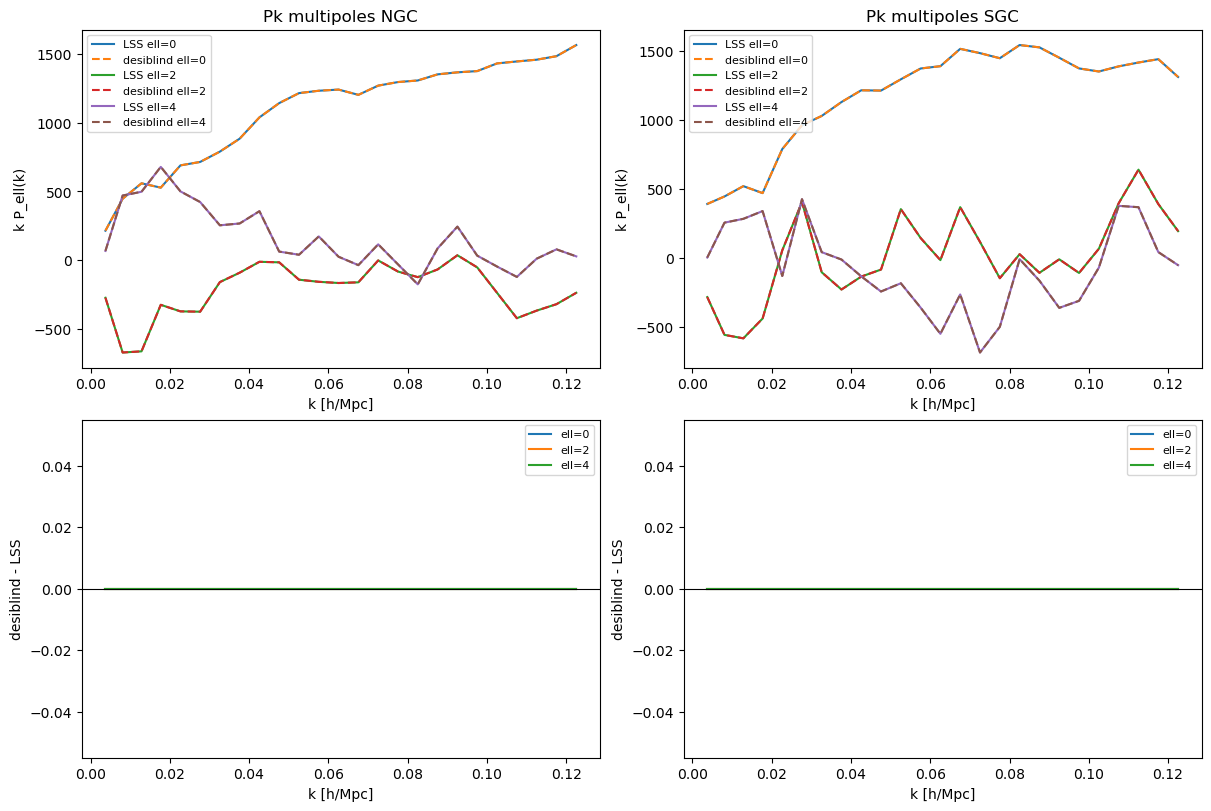

In [12]:
import lsstypes as types


def stat_pair(summary, region, stat_prefix):
    root = Path(summary['output_dir']) / 'stats' / region
    lss = sorted((root / 'lss').glob(f'{stat_prefix}*_{region}_*_lss.h5'))
    desiblind = sorted((root / 'desiblind').glob(f'{stat_prefix}*_{region}_*_desiblind.h5'))
    assert len(lss) == 1 and len(desiblind) == 1, (root, lss, desiblind)
    return lss[0], desiblind[0]


def read_pk_poles(path, ells=(0, 2, 4)):
    spectrum = types.read(path)
    poles = {}
    for ell in ells:
        pole = spectrum.get(ell)
        poles[ell] = (np.asarray(pole.coords()['k']), np.asarray(pole.value()))
    return poles


pk_summary = summaries['pk_stats']
fig, axes = plt.subplots(2, 2, figsize=(12, 8), constrained_layout=True)
for col, region in enumerate(pk_summary['regions']):
    lss_fn, desi_fn = stat_pair(pk_summary, region, 'mesh2_spectrum')
    lss_curves, desi_curves = read_pk_poles(lss_fn), read_pk_poles(desi_fn)
    ax, rax = axes[0, col], axes[1, col]
    for ell, (k, value) in sorted(lss_curves.items()):
        dvalue = desi_curves[ell][1]
        ax.plot(k, k * value, label=f'LSS ell={ell}')
        ax.plot(k, k * dvalue, '--', label=f'desiblind ell={ell}')
        residual = dvalue - value
        rax.plot(k, residual, label=f'ell={ell}')
        assert np.max(np.abs(residual)) <= 1e-9
        print(region, f'ell={ell}', 'max residual', float(np.max(np.abs(residual))))
    ax.set_title(f'Pk multipoles {region}')
    ax.set_xlabel('k [h/Mpc]')
    ax.set_ylabel('k P_ell(k)')
    ax.legend(fontsize=8)
    rax.set_xlabel('k [h/Mpc]')
    rax.set_ylabel('desiblind - LSS')
    rax.axhline(0, color='k', lw=0.8)
    rax.legend(fontsize=8)
plt.show()


### xi multipoles from the built-in projection

The xi validation used a staged 50k-random subset for speed. The residual is at roundoff level.


NGC ell=0 max residual 2.498001805406602e-16
NGC ell=2 max residual 4.718447854656915e-16
NGC ell=4 max residual 7.4593109467002705e-16
SGC ell=0 max residual 2.740863092043355e-16
SGC ell=2 max residual 6.661338147750939e-16
SGC ell=4 max residual 8.326672684688674e-16


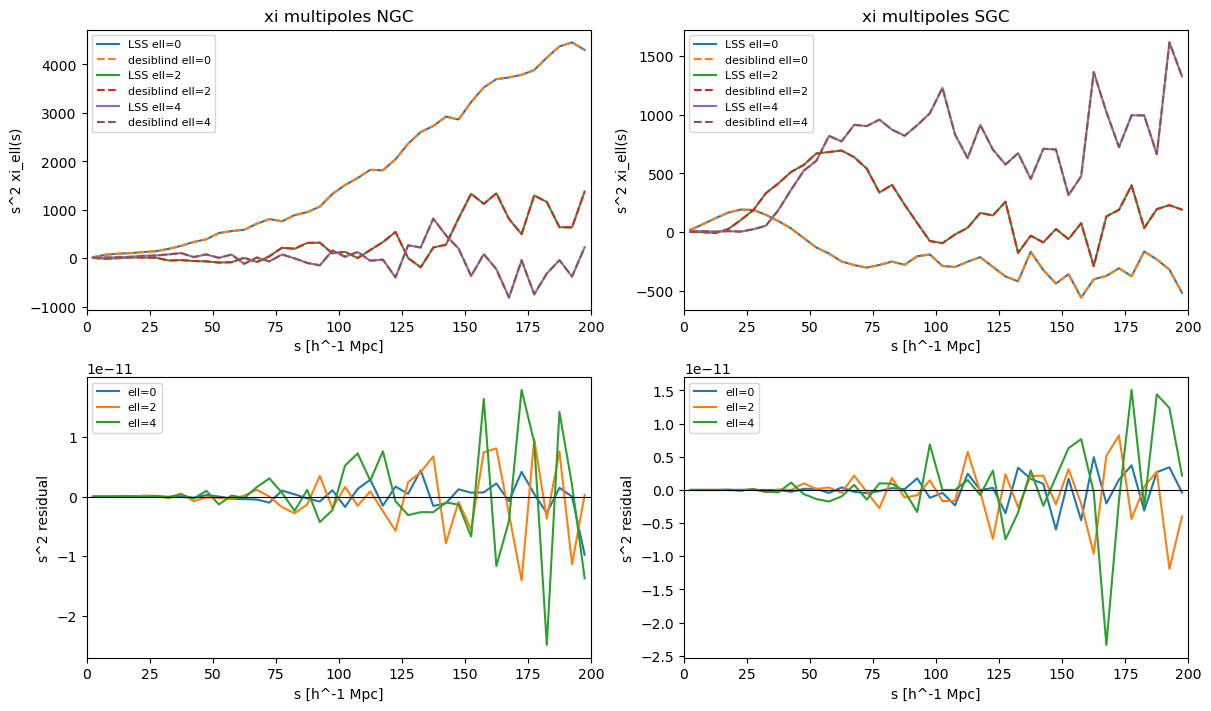

In [13]:
def xi_builtin_multipoles(correlation, ells=(0, 2, 4)):
    poles = {}
    s = None
    for ell in ells:
        pole = correlation.project(ell=ell)
        pole_s = np.asarray(pole.coords()['s'])
        pole_value = np.asarray(pole.value())
        if s is None:
            s = pole_s
        else:
            assert np.allclose(s, pole_s)
        poles[ell] = pole_value
    return s, poles


xi_summary = summaries['xi_stats']
fig, axes = plt.subplots(2, 2, figsize=(12, 7), constrained_layout=True)
for col, region in enumerate(xi_summary['regions']):
    lss_fn, desi_fn = stat_pair(xi_summary, region, 'particle2_correlation')
    lss_corr = types.read(lss_fn)
    desi_corr = types.read(desi_fn)
    s, lss_poles = xi_builtin_multipoles(lss_corr)
    _, desi_poles = xi_builtin_multipoles(desi_corr)
    ax = axes[0, col]
    rax = axes[1, col]
    for ell in [0, 2, 4]:
        scale = s**2
        ax.plot(s, scale * lss_poles[ell], label=f'LSS ell={ell}')
        ax.plot(s, scale * desi_poles[ell], linestyle='--', label=f'desiblind ell={ell}')
        residual = desi_poles[ell] - lss_poles[ell]
        rax.plot(s, scale * residual, label=f'ell={ell}')
        assert np.max(np.abs(residual)) <= 1e-10
        print(region, f'ell={ell}', 'max residual', float(np.max(np.abs(residual))))
    ax.set_title(f'xi multipoles {region}')
    ax.set_xlabel('s [h^-1 Mpc]')
    ax.set_ylabel('s^2 xi_ell(s)')
    ax.set_xlim(0, 200)
    ax.legend(fontsize=8)
    rax.set_xlabel('s [h^-1 Mpc]')
    rax.set_ylabel('s^2 residual')
    rax.set_xlim(0, 200)
    rax.axhline(0, color='k', lw=0.8)
    rax.legend(fontsize=8)
plt.show()


## Final conclusion

The RSD validation ladder passes through all sampled integration layers:

- direct LSS RSD redshift-shift comparison;
- real-subset `IFFTrsd` reconstruction comparison;
- saved-catalog workflow with BAO/AP, `mkclusdat`, `mkclusran`, GC split, `IFFTrsd`, and final RSD shift;
- full-row one-random saved-catalog LSS-reference validation;
- `desi-clustering` saved-catalog driver validation for both direct `pyrecon` and matched-convention `jaxrecon` backends;
- `desi-clustering` Pk and xi measurement-layer checks.

For the driver backends, the important convention choices are now explicit: `jaxrecon` must use the same data-derived box center as pyrecon and the pyrecon scalar random-threshold convention (`threshold_randoms_method='mean'`). With those conventions, both backends reproduce the LSS/pyrecon final RSD-blinded `Z` at numerical precision on the 2k-row NGC/SGC validation subsets. The remaining open question for choosing `jaxrecon` as the default on-the-fly backend is performance/scaling, not reference compatibility on these subsets.


In [14]:
print('catalog_rsd_validation=PASS')
print('saved_large_summary    =', SUMMARY_PATHS['saved_large'])
print('saved_fullrow_summary  =', SUMMARY_PATHS['saved_fullrow'])
print('driver_backends_summary=', SUMMARY_PATHS['driver_backends'])
print('pk_stats_summary       =', SUMMARY_PATHS['pk_stats'])
print('xi_stats_summary       =', SUMMARY_PATHS['xi_stats'])


catalog_rsd_validation=PASS
saved_large_summary    = /pscratch/sd/u/uendert/desiblind_lss_validation/rsd-saved-catalog-20260629-160133-759367/summary.json
saved_fullrow_summary  = /pscratch/sd/u/uendert/desiblind_lss_validation/rsd-saved-catalog-fullrow-ran0-lssrecon-20260630-132632-308997/summary.json
driver_backends_summary= /pscratch/sd/u/uendert/desiblind_lss_validation/rsd-desi-clustering-driver-20260630-185228-1058512/summary.json
pk_stats_summary       = /pscratch/sd/u/uendert/desiblind_lss_validation/rsd-desi-clustering-stats-20260629-160601-1746031/summary.json
xi_stats_summary       = /pscratch/sd/u/uendert/desiblind_lss_validation/rsd-desi-clustering-stats-20260629-160817-905849/summary.json
